# MNIST Classification

🎯 <b><u>Exercise objectives</u></b>
- Understand the *MNIST* dataset 
- Design your first **Convolutional Neural Network** (*CNN*) and answer questions such as:
    - what are *Convolutional Layers*? 
    - how many *parameters* are involved in such a layer?
- Train this CNN on images

🚀 <b><u>Let's get started!</u></b>

Imagine that we are  back in time into the 90's.
You work at a *Post Office* and you have to deal with an enormous amount of letters on a daily basis. How could you automate the process of reading the ZIP Codes, which are a combination of 5 handwritten digits? 

This task, called the **Handwriting Recognition**, used to be a very complex problem back in those days. It was solved by *Bell Labs* (among others) where one of the Deep Learning gurus, [*Yann Le Cun*](https://en.wikipedia.org/wiki/Yann_LeCun), used to work.

From [Wikipedia](https://en.wikipedia.org/wiki/Handwriting_recognition):

> Handwriting recognition (HWR), also known as Handwritten Text Recognition (HTR), is the ability of a computer to receive and interpret intelligible handwritten input from sources such as paper documents, photographs, touch-screens and other devices

![Number recognition](recognition.gif)

*Note: The animation above is just here to help you visualize what happens with the different images: <br/> $\rightarrow$ For each image, once the CNN is trained, it will predict what digit is written. The inputs are the different digits and not one animation/video!*

🤔 <b><u>How does this CNN work ?</u></b>

- *Inputs*: Images (_each image shows a handwritten digit_)
- *Target*: For each image, you want your CNN model to predict the correct digit (between 0 and 9)
    - It is a **multi-class classification** task (more precisely a 10-class classification task since there are 10 different digits).

🔢 To improve the capacity of the Convolutional Neural Network to read these numbers, we need to feed it with many images representing handwritten digits. This is why the 📚 [**MNIST dataset**](http://yann.lecun.com/exdb/mnist/) *(Mixed National Institute of Standards and Technology)* was created.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## (1) The `MNIST` Dataset

📚 Tensorflow/Keras offers multiple [**datasets**](https://www.tensorflow.org/api_docs/python/tf/keras/datasets) to play with:
- *Vectors*: `boston_housing` (regression)
- *Images* : `mnist`, `fashion_mnist`, `cifar10`, `cifar100` (classification)
- *Texts*: `imbd`, `reuters` (classification/sentiment analysis)


💾 You can **load the MNIST dataset** with the following commands:

In [2]:
from keras import datasets


# Loading the MNIST Dataset...
(X_train, y_train), (X_test, y_test) = datasets.mnist.load_data(path="mnist.npz")

# The train set contains 60 000 images, each of them of size 28x28
# The test set contains 10 000 images, each of them of size 28x28
(X_train.shape, y_train.shape), (X_test.shape, y_test.shape)

2026-05-15 11:27:35.512236: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-15 11:27:35.528013: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-15 11:27:35.667114: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-15 11:27:35.828403: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-15 11:27:35.990851: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registe

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


(((60000, 28, 28), (60000,)), ((10000, 28, 28), (10000,)))

### (1.1) Exploring the dataset

❓ **Question: Let's have look at some handwritten digits of this MNIST dataset.** ❓

🖨 Print some images from the *train set*.

<details>
    <summary><i>Hints</i></summary>

💡*Hint*: use the `imshow` function from `matplotlib` with `cmap = "gray"`

🤨 Note: if you don't specify this *cmap* argument, the weirdly displayed colors are just Matplotlib defaults...
    
</details>

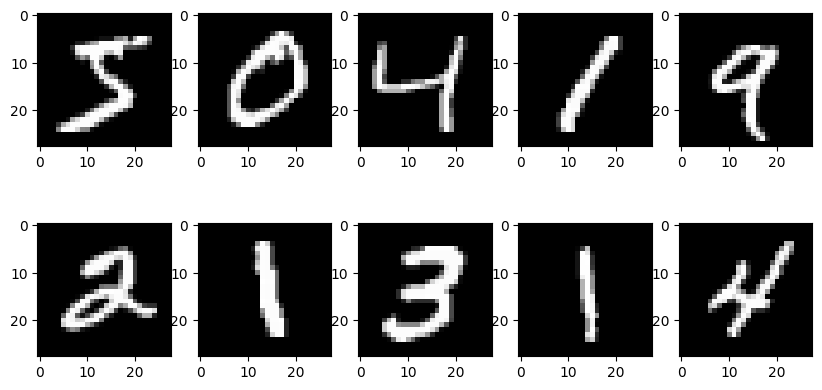

In [ ]:
# YOUR CODE HERE
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2, 5, i+1)
    #here I just show the position of my plot
    plt.imshow(X_train[i], cmap='gray')
    #In the show I say to show which picture
plt.show()

### (1.2) Image Preprocessing

❗️ **Neural Networks converge faster when the input data is somehow normalized** ❗️

👩🏻‍🏫 How do we proceed for Convolutional Neural Networks ?
* The `RBG` intensities are coded between 0 and 255. 
* We can simply divide the input data by the maximal value 255 to have all the pixels' intensities between 0 and 1 😉

❓ **Question ❓ As a first preprocessing step, please normalize your data.** 

Don't forget to do it both on your train data and your test data.

(*Note: you can also center your data, by subtracting 0.5 from all the values, but it is not mandatory*)

In [5]:
# YOUR CODE HERE
X_train = X_train / 255
X_test = X_test / 255

### (1.3) Inputs' dimensionality

In [6]:
print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


👆 Remember that you have 60,000 training images and 10,000 test images, each of size $(28, 28)$. However...

> ❗️  **`Convolutional Neural Network models need to be fed with images whose last dimension is the number of channels`.**  

> 🧑🏻‍🏫 The shape of tensors fed into ***ConvNets*** is the following: `(NUMBER_OF_IMAGES, HEIGHT, WIDTH, CHANNELS)`

🕵🏻This last dimension is clearly missing here. Can you guess the reason why?
<br>
<details>
    <summary><i>Answer<i></summary>
        
* All these $60000$ $ (28 \times 28) $ pictures are black-and-white $ \implies $ Each pixel lives on a spectrum from full black (0) to full white (1).
        
    * Theoretically, you don't need to know the number of channels for a black-and-white picture since there is only 1 channel (the "whiteness" of "blackness" of a pixel). However, it is still mandatory for the model to have this number of channels explicitly stated.
        
    * In comparison, colored pictures need multiple channels:
        - the RGB system with 3 channels (<b><span style="color:red">Red</span> <span style="color:green">Green</span> <span style="color:blue">Blue</span></b>)
        - the CYMK system  with 4 channels (<b><span style="color:cyan">Cyan</span> <span style="color:magenta">Magenta</span> <span style="color:yellow">Yellow</span> <span style="color:black">Black</span></b>)
        
        
</details>        

❓ **Question: expanding dimensions** ❓

* Use the **`expand_dims`** to add one dimension at the end of the training data and test data.

* Then, print the shapes of `X_train` and `X_test`. They should respectively be equal to $(60000, 28, 28, 1)$ and $(10000, 28, 28, 1)$.

In [7]:
from keras.ops import expand_dims

In [8]:
# YOUR CODE HERE

X_train = expand_dims(X_train, axis=-1)
X_test = expand_dims(X_test, axis=-1)

print(X_train.shape)
print(X_test.shape)

2026-05-15 11:42:12.888744: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-15 11:42:12.890141: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


(60000, 28, 28, 1)
(10000, 28, 28, 1)


### (1.4) Target encoding

One more thing to do for a multiclass classification task in Deep Leaning:

👉 _"one-hot-encode" the categories*_

❓ **Question: encoding the labels** ❓ 

* Use **`to_categorical`** to transform your labels. 
* Store the results into two variables that you can call **`y_train_cat`** and **`y_test_cat`**.

In [9]:
from keras.utils import to_categorical

# YOUR CODE HERE
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

In [10]:
# Quick check that you correctly used to_categorical
assert(y_train_cat.shape == (60000,10))
assert(y_test_cat.shape == (10000,10))

The data is now ready to be used. ✅

## (2) The Convolutional Neural Network

### (2.1) Architecture and compilation of a CNN


❓ **Question: CNN Architecture and compilation** ❓

Now, let's build a <u>Convolutional Neural Network</u> that has: 


- a `Conv2D` layer with 8 filters, each of size $(4, 4)$, an input shape suitable for your task, the `relu` activation function, and `padding='same'`
- a `MaxPool2D` layer with a `pool_size` equal to $(2, 2)$
- a second `Conv2D` layer with 16 filters, each of size $(3, 3)$, and the `relu` activation function
- a second `MaxPool2D` layer with a `pool_size` equal to $(2, 2)$


- a `Flatten` layer
- a first `Dense` layer with 10 neurons and the `relu` activation function
- a last (predictive) layer that is suited for your task

In the function that initializes this model, do not forget to include the <u>compilation of the model</u>, which:
* optimizes the `categorical_crossentropy` loss function,
* with the `adam` optimizer, 
* and the `accuracy` as the metrics

(*Note: you could add more classification metrics if you want but the dataset is well balanced!*)

In [ ]:
from keras import Sequential, Input, layers


def initialize_model():

    model = Sequential()

    ### First Convolution & MaxPooling
    model.add(Input(shape=(28, 28, 1)))
    model.add(layers.Conv2D(8, (4, 4), activation='relu', padding='same'))
    model.add(layers.MaxPool2D(pool_size=(2, 2)))

    ### Second Convolution & MaxPooling
    model.add(layers.Conv2D(16, (3, 3), activation='relu'))
    model.add(layers.MaxPool2D(2,2))

    ### Flattening
    model.add(layers.Flatten())

    ### One Fully Connected layer - "Fully Connected" is equivalent to saying "Dense"
    model.add(layers.Dense(10, activation='relu'))

    ### Last layer - Classification Layer with 10 outputs corresponding to 10 digits
    model.add(layers.Dense(10, activation='softmax'))

    ### Model compilation
    # YOUR CODE HERE
    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model

❓ **Question: number of trainable parameters in a convolutional layer** ❓ 

How many trainable parameters are there in your model?
1. Compute them with ***model.summary( )*** first
2. Recompute them manually to make sure you properly understood ***what influences the number of weights in a CNN***.

In [14]:
# YOUR CODE HERE
model = initialize_model()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 8)      │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         5,770 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,184 (28.06 KB)

 Trainable params: 7,184 (28.06 KB)

 Non-trainable params: 0 (0.00 B)

### (2.2) Training a CNN

❓ **Question: training a CNN** ❓ 

Initialize your model and fit it on the train data. 
- Do not forget to use a **Validation Set/Split** and an **Early Stopping criterion**. 
- Limit yourself to 5 epochs max in this challenge, just to save some precious time for the more advanced challenges!

In [16]:
from keras.callbacks import EarlyStopping

# YOUR CODE HERE

es = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train_cat,
    validation_split=0.3,
    epochs= 10,
    batch_size=32,
    callbacks=[es],
    verbose=1
)

Epoch 1/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.8452 - loss: 0.5041 - val_accuracy: 0.9434 - val_loss: 0.1996
Epoch 2/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.9536 - loss: 0.1598 - val_accuracy: 0.9619 - val_loss: 0.1340
Epoch 3/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.9669 - loss: 0.1105 - val_accuracy: 0.9683 - val_loss: 0.1106
Epoch 4/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.9724 - loss: 0.0912 - val_accuracy: 0.9720 - val_loss: 0.0965
Epoch 5/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.9772 - loss: 0.0765 - val_accuracy: 0.9771 - val_loss: 0.0837
Epoch 6/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.9794 - loss: 0.0679 - val_accuracy: 0.9747 - val_loss: 0.0856
Epoch 7/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.9817 - loss: 0.0610 - val_accuracy: 0.9786 - val_loss: 0.0740
Epoch 8/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.9828 -

❓ **Question: How many iterations does the CNN perform per epoch** ❓

_Note: it has nothing to do with the fact that this is a CNN. This is related to the concept of forward/backward propagation already covered during the previous lecture on optimizers, fitting, and losses 😉_

> YOUR ANSWER HERE

<details>
    <summary><i>Answer</i></summary>

With `verbose = 1` when fitting your model, you have access to crucial information about your training procedure.
    
Remember that we've just trained our CNN model on $60000$ training images

If the chosen batch size is 32: 

* For each epoch, we have $ \large \lceil \frac{60000}{32} \rceil = 1875$ minibatches <br/>
* The _validation_split_ is equal to $0.3$ - which means that within one single epoch, there are:
    * $ \lceil 1875 \times (1 - 0.3) \rceil = \lceil 1312.5 \rceil = 1313$ batches are used to compute the `train_loss` 
    * $ 1875 - 1312 = 562 $ batches are used to compute the `val_loss`
    * **The parameters are updated 1313 times per epoch** as there are 1313 forward/backward propagations per epoch !!!


👉 With so many updates of the weights within one epoch, you can understand why this CNN model converges even with a limited number of epochs.

</details>    


### (2.3) Evaluating its performance

❓ **Question: Evaluating your CNN** ❓ 

What is your **`accuracy on the test set?`**

In [18]:
# YOUR CODE HERE
test_eval = model.evaluate(X_test, y_test_cat, verbose=0)

test_eval

[0.05764036998152733, 0.983299970626831]

🎉 You should already be impressed by your CNN skills! Reaching over 95% accuracy!

🔥 You solved what was a very hard problem 30 years ago with your own CNN.

🏁 **Congratulations!**

💾 Don't forget to `git add/commit/push` your notebook...

🚀 ... and move on to the next challenge!